This Code produces 4 Figures visualizing the 
1) Mass -
2) Scale -
3) Phase -
4) Measurement length -
   
-dependence of the timing resiudal.

In [2]:
import os
os.chdir(os.path.dirname(os.getcwd()))

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
from src.residual_fct import timing_residual
from src.plotting import axes_plot

In [4]:
#given parameters 
G = 6.7e-39 #GeV^-2
chi = 1.6e35 #GeV^-1
T = 7.6e21 #GeV^-1
rho = 2.3e-42  #GeV^4
delta = 0.1
H = 1.5e-42 #GeV 
a = 1.0
deltadot = H*delta /(2*np.sqrt(np.pi))

In [5]:
#reference values (green in plots):
k1 = 100/1.56e38 #GeV
theta1 = 0.75*np.pi
m1 = 1e-33  #GeV
tend1 = 10*4.8e31 #GeV^-1

print('m_1 ~ ', np.round(m1*1e9*1e24, 0), 'e-24 eV')
print('theta_1 ~ ', np.round(theta1/np.pi, 1), ' pi')
print('k_1 ~ ', np.round(k1*1.56e38, 0), ' Mpc^-1')
print('tend_1 ~ ', np.round(tend1/(4.8e31), 0), ' yr')

m_1 ~  1.0 e-24 eV
theta_1 ~  0.8  pi
k_1 ~  100.0  Mpc^-1
tend_1 ~  10.0  yr


In [6]:
k0 = np.sqrt(12*np.pi*G*rho) #Horizon-Crossing / critical k: 
#variable ranges:
m = np.logspace(-33.5, -31, 1500)  #GeV
theta = np.linspace(0.0, np.pi, 100)
k = np.unique(np.r_[np.logspace(np.log10(0.01*H), np.log10(0.01*m1), 100), #GeV #this is k/a not k
                    np.logspace(np.log10(0.7*k0), np.log10(1.3*k0), 80)])  #extra points near k ~ H

tend = np.linspace(1e31, 10**33.7, 150)  #GeV^-1

In [7]:
#Residual
def R(tend, theta, k, m):
    return timing_residual(G, chi, T, rho, delta, H, a, deltadot, m, theta, k, tend)

res_m = np.array([R(tend1, theta1, k1, m_) for m_ in m]) * 6.57e-19 #microsec
res_k = np.array([R(tend1, theta1, k_, m1) for k_ in k]) * 6.57e-19 #microsec
res_theta = np.array([R(tend1, theta_, k1, m1) for theta_ in theta]) * 6.57e-19 #microsec
res_tend = np.array([R(tend_, theta1, k1, m1) for tend_ in tend]) * 6.57e-19 #microsec

In [8]:
#Plotting
p_read = 1.5 #factor for fontsize of axes, ticks, legend
savefig = True  #saves Figures if True

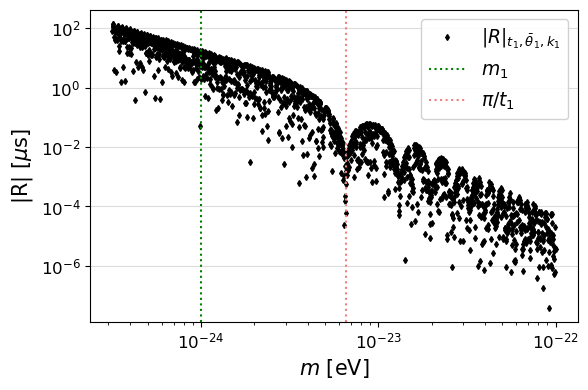

In [9]:
#plot_m_dependence
fig, ax = plt.subplots(figsize=(6, 4)) 
axes_plot(ax, m*1e9, np.abs(res_m), label=r'$|R|_{t_1, \bar\theta_1, k_1}$', xscale='log', yscale='log',  
          xlabel=r'$m$ [eV]', ylabel=r'|R| [$\mu$s]', p_read=p_read)
ax.axvline(m1*1e9, linestyle=':', color='green', label=r'$m_1$')
ax.axvline(np.pi*1e9/tend1, linestyle=':', color='lightcoral', label=r'$\pi/t_1$')
ax.legend(fontsize=9*p_read, framealpha=0.9)
if savefig: plt.savefig('figures/R_m_dependence.png', dpi=300, bbox_inches="tight")
plt.show()

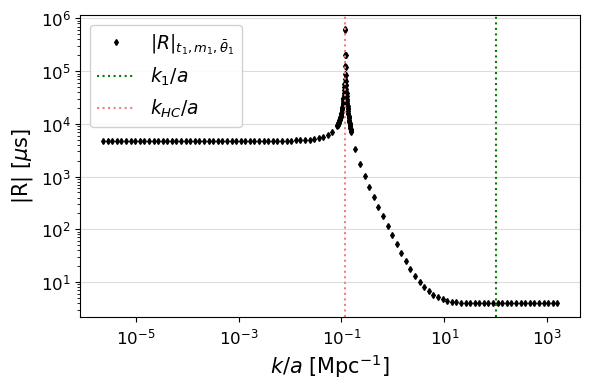

In [10]:
#plot_k_dependence
fig, ax = plt.subplots(figsize=(6, 4)) 
axes_plot(ax, k*1.56e38, np.abs(res_k), label=r'$|R|_{t_1, m_1, \bar\theta_1}$', xscale='log', yscale='log',  
          xlabel=r'$k/a$ [Mpc$^{-1}$]', ylabel=r'|R| [$\mu$s]', p_read=p_read)
ax.axvline(k1*1.56e38, linestyle=':', color='green', label=r'$k_1/a$')
ax.axvline(k0*1.56e38, linestyle=':', color='lightcoral', label=r'$k_{HC}/a$')
ax.legend(fontsize=9*p_read, framealpha=0.9)
if savefig: plt.savefig('figures/R_k_dependence.png', dpi=300, bbox_inches="tight")
plt.show()

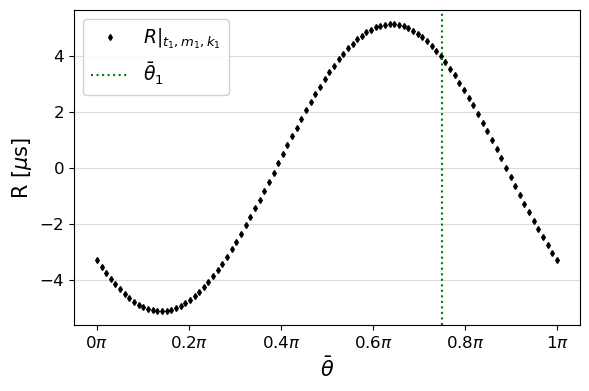

In [11]:
#plot_theta_dependence
fig, ax = plt.subplots(figsize=(6, 4)) 
axes_plot(ax, theta, res_theta, label=r'$R|_{t_1, m_1, k_1}$',   
          xlabel=r'$\bar\theta$', ylabel=r'R [$\mu$s]', p_read=p_read)
ax.axvline(theta1, linestyle=':', color='green', label=r'$\bar\theta_1$')
#change x-axis ticks to multiples of pi/5 
ax.xaxis.set_major_locator(MultipleLocator(np.pi/5))          
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: rf"${x/np.pi:.2g}\pi$"))
ax.legend(fontsize=9*p_read, framealpha=0.9)
if savefig: plt.savefig('figures/R_theta_dependence.png', dpi=300, bbox_inches="tight")
plt.show()

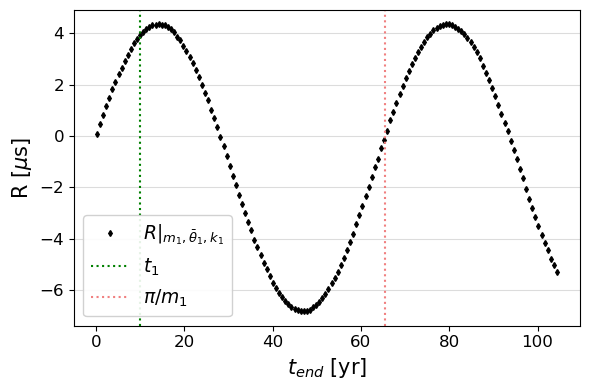

In [12]:
#plot_tend_dependence
fig, ax = plt.subplots(figsize=(6, 4)) 
axes_plot(ax, tend/(4.8e31), res_tend, label=r'$R|_{m_1, \bar\theta_1, k_1}$',   
          xlabel=r'$t_{end}$ [yr]', ylabel=r'R [$\mu$s]', p_read=p_read)
ax.axvline(tend1/(4.8e31), linestyle=':', color='green', label=r'$t_1$')
ax.axvline(np.pi/(m1*4.8e31), linestyle=':',  color='lightcoral', label=r'$\pi/m_1$')
ax.legend(fontsize=9*p_read, framealpha=0.9)
if savefig: plt.savefig('figures/R_tend_dependence.png', dpi=300, bbox_inches="tight")
plt.show()